# 共享单车用户 RFM 分层 - Part 3：分析与评估 (C6-C10)

读取 Part 2 的 `../data/rfm_clustered.csv`

### 读取 Part 2 数据

In [1]:
# ============================================================
# 读取聚类后的数据
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.float_format", lambda x: "%.2f" % x)
import warnings; warnings.filterwarnings("ignore")

rfm = pd.read_csv("../data/rfm_clustered.csv")
best_k = rfm["cluster"].nunique()
print(f"读取数据: {rfm.shape[0]} 用户, {best_k} 个簇")
print(f"列: {rfm.columns.tolist()}")
rfm.head()

读取数据: 16883 用户, 3 个簇
列: ['userid', 'R', 'F', 'M', 'R_SC', 'F_SC', 'M_SC', 'cluster']


,userid,R,F,M,R_SC,F_SC,M_SC,cluster
0,1,0,5,7.18,-0.79,-0.30,-0.35,2
1,3,3,8,8.49,-0.22,0.56,-0.15,2
2,6,0,2,2.58,-0.79,-1.17,-1.06,2
3,7,6,8,10.49,0.35,0.56,0.16,0
4,8,4,7,7.09,-0.03,0.27,-0.36,2


### C6 各簇特征分析

**各簇 RFM 均值汇总表**

In [2]:
# ============================================================
# 各簇 RFM 特征汇总表
# 按簇聚合计算 R/F/M 均值 + 用户数 + 占比
# ============================================================
cluster_analysis = rfm.groupby("cluster").agg(
    R_mean=("R", "mean"),
    F_mean=("F", "mean"),
    M_mean=("M", "mean"),
    用户数=("userid", "nunique")
).round(1)

cluster_analysis["占比(%)"] = (
    cluster_analysis["用户数"] / cluster_analysis["用户数"].sum() * 100
).round(1)

# 全量均值作为参考基准
print("全量均值（参考线）：")
print(f"  R = {rfm['R'].mean():.1f} 天  |  "
      f"F = {rfm['F'].mean():.1f} 次  |  "
      f"M = {rfm['M'].mean():.1f} km")
print()
print("各簇特征汇总：")
cluster_analysis


全量均值（参考线）：
  R = 4.1 天  |  F = 6.1 次  |  M = 9.4 km

各簇特征汇总：


,R_mean,F_mean,M_mean,用户数,占比(%)
cluster,,,,,
0,2.20,9.80,16.40,5696,33.70
1,15.30,3.60,5.40,2174,12.90
2,2.70,4.30,6.00,9013,53.40


**R 各簇对比**

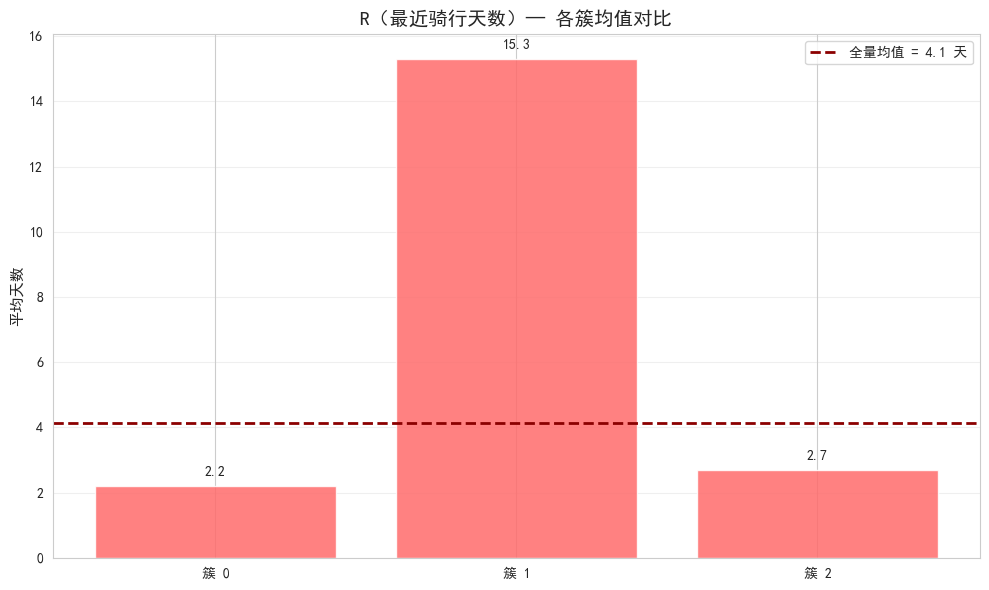

In [3]:
# ============================================================
# 图表：R（最近骑行天数）各簇均值对比
# 柱越低 → 用户越活跃
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

vals = cluster_analysis["R_mean"]
bars = ax.bar(range(best_k), vals, color="#FF6B6B", edgecolor="white", alpha=0.85)

# 全量均值参考线
overall_r = rfm["R"].mean()
ax.axhline(overall_r, color="darkred", linestyle="--", linewidth=2,
           label=f"全量均值 = {overall_r:.1f} 天")

# 柱顶标注数值
for j, v in enumerate(vals):
    ax.text(j, v + max(vals) * 0.02, f"{v:.1f}",
            ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(range(best_k))
ax.set_xticklabels([f"簇 {c}" for c in range(best_k)])
ax.set_title("R（最近骑行天数）— 各簇均值对比", fontsize=14, fontweight="bold")
ax.set_ylabel("平均天数", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


**F 各簇对比**

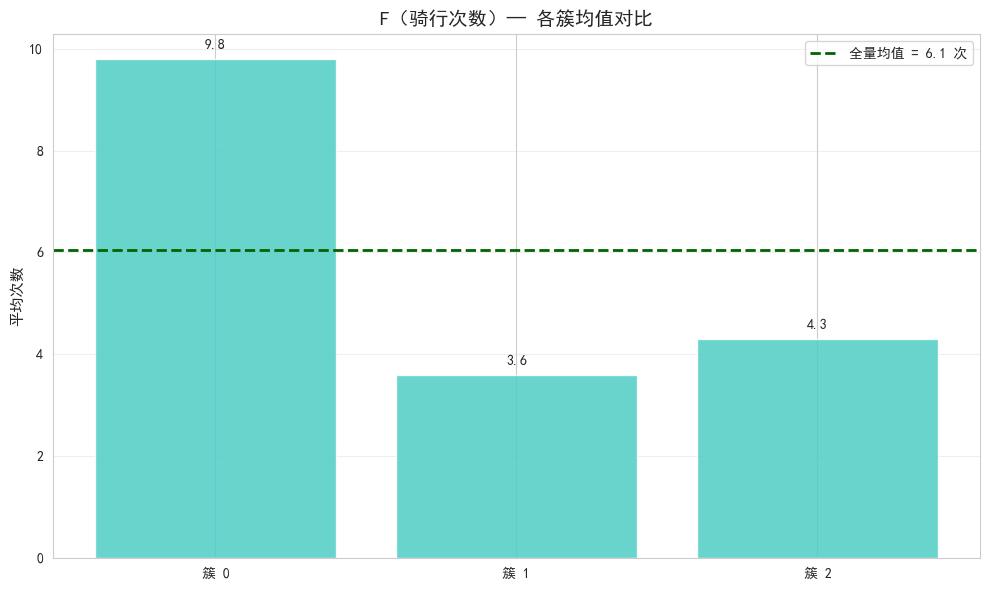

In [4]:
# ============================================================
# 图表：F（骑行次数）各簇均值对比
# 柱越高 → 用户越忠诚
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

vals = cluster_analysis["F_mean"]
ax.bar(range(best_k), vals, color="#4ECDC4", edgecolor="white", alpha=0.85)

overall_f = rfm["F"].mean()
ax.axhline(overall_f, color="darkgreen", linestyle="--", linewidth=2,
           label=f"全量均值 = {overall_f:.1f} 次")

for j, v in enumerate(vals):
    ax.text(j, v + max(vals) * 0.02, f"{v:.1f}",
            ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(range(best_k))
ax.set_xticklabels([f"簇 {c}" for c in range(best_k)])
ax.set_title("F（骑行次数）— 各簇均值对比", fontsize=14, fontweight="bold")
ax.set_ylabel("平均次数", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


**M 各簇对比**

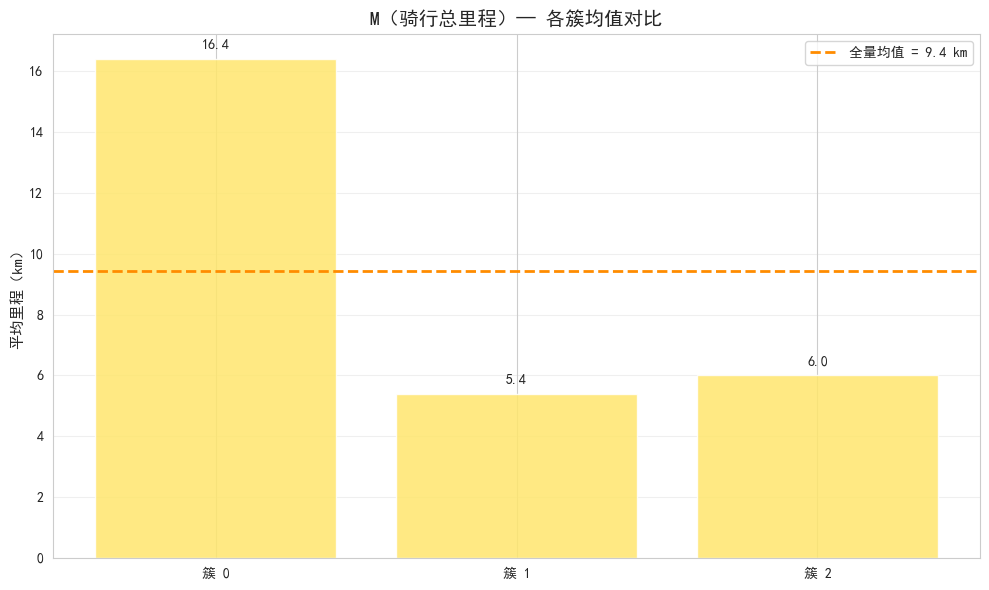

In [5]:
# ============================================================
# 图表：M（骑行总里程）各簇均值对比
# 柱越高 → 用户价值越高
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

vals = cluster_analysis["M_mean"]
ax.bar(range(best_k), vals, color="#FFE66D", edgecolor="white", alpha=0.85)

overall_m = rfm["M"].mean()
ax.axhline(overall_m, color="darkorange", linestyle="--", linewidth=2,
           label=f"全量均值 = {overall_m:.1f} km")

for j, v in enumerate(vals):
    ax.text(j, v + max(vals) * 0.02, f"{v:.1f}",
            ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(range(best_k))
ax.set_xticklabels([f"簇 {c}" for c in range(best_k)])
ax.set_title("M（骑行总里程）— 各簇均值对比", fontsize=14, fontweight="bold")
ax.set_ylabel("平均里程（km）", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### C7 价值等级划分

**各簇综合得分排名表**

In [6]:
# ============================================================
# 计算各簇综合得分
# 权重：R(-0.25) + F(0.35) + M(0.40)
# R 越小越好 → 负权重；F/M 越大越好 → 正权重
# ============================================================
cluster_analysis["综合得分"] = (
    -cluster_analysis["R_mean"] * 0.25
    + cluster_analysis["F_mean"] * 0.35
    + cluster_analysis["M_mean"] * 0.40
).round(2)

# 按得分降序排列
cluster_ranked = cluster_analysis.sort_values("综合得分", ascending=False)

print("各簇综合得分排名（从高到低）：")
cluster_ranked[["R_mean", "F_mean", "M_mean", "用户数", "占比(%)", "综合得分"]]


各簇综合得分排名（从高到低）：


,R_mean,F_mean,M_mean,用户数,占比(%),综合得分
cluster,,,,,,
0,2.20,9.80,16.40,5696,33.70,9.44
2,2.70,4.30,6.00,9013,53.40,3.23
1,15.30,3.60,5.40,2174,12.90,-0.41


**簇 → 等级映射**

In [7]:
# ============================================================
# 按得分排名映射 S/A/B/C/D 等级
# 第 1 名 → S 级，第 2 名 → A 级 ... 依此类推
# ============================================================
level_names = ["S", "A", "B", "C", "D"][:best_k]

level_map = {}
for rank, cluster_id in enumerate(cluster_ranked.index):
    level_map[cluster_id] = level_names[rank]
    print(f"簇 {cluster_id}（第 {rank+1} 名）→ {level_names[rank]} 级")

# 为用户标注等级
rfm["level"] = rfm["cluster"].map(level_map)

print()
print("标注结果（前 10 行）：")
rfm[["userid", "R", "F", "M", "cluster", "level"]].head(10)


簇 0（第 1 名）→ S 级
簇 2（第 2 名）→ A 级
簇 1（第 3 名）→ B 级

标注结果（前 10 行）：


,userid,R,F,M,cluster,level
0,1,0,5,7.18,2,A
1,3,3,8,8.49,2,A
2,6,0,2,2.58,2,A
3,7,6,8,10.49,0,S
4,8,4,7,7.09,2,A
5,9,1,10,9.03,0,S
6,10,0,7,10.06,2,A
7,11,0,6,6.08,2,A
8,12,4,1,0.86,2,A
9,13,15,4,5.30,1,B


### C8 可视化展示

**饼图**

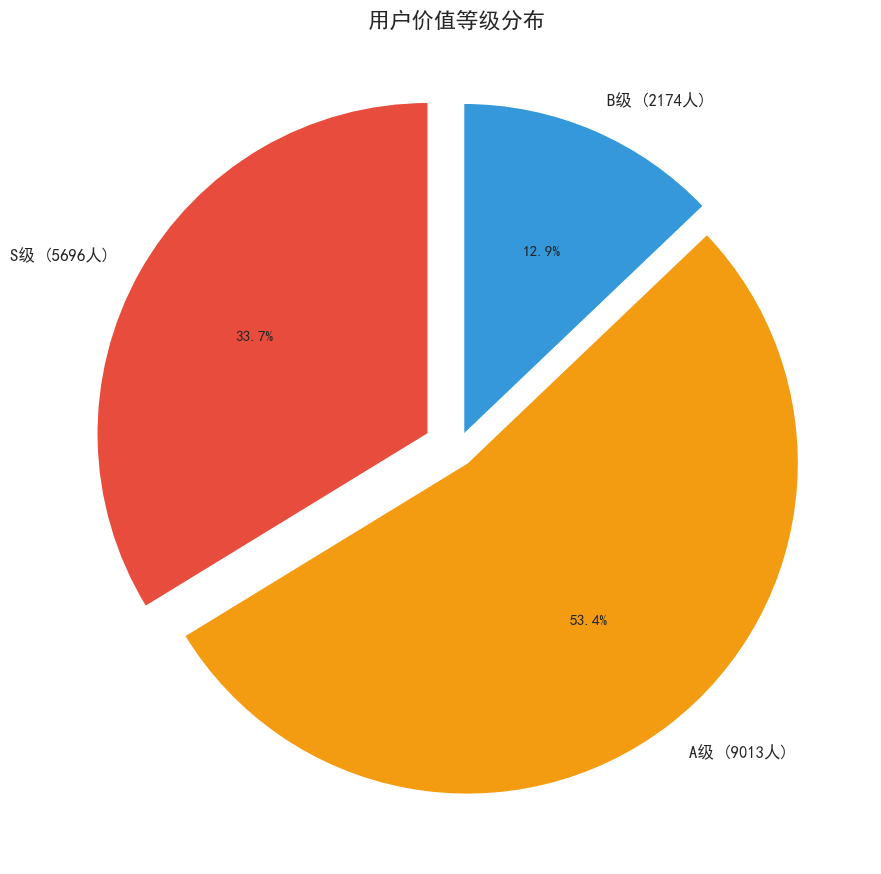

各等级汇总：
  S 级:   5696 人  ( 33.7%)
  A 级:   9013 人  ( 53.4%)
  B 级:   2174 人  ( 12.9%)


In [8]:
# ============================================================
# 图表：用户价值等级分布 — 饼图
# ============================================================
level_counts = rfm["level"].value_counts()
level_order = ["S", "A", "B", "C", "D"][:best_k]
level_counts = level_counts.reindex(
    [l for l in level_order if l in level_counts.index]
)

colors_pie = ["#E74C3C", "#F39C12", "#3498DB", "#2ECC71", "#95A5A6"][:len(level_counts)]
explode = [0.05] * len(level_counts)
explode[0] = 0.1   # S 级突出显示

fig, ax = plt.subplots(figsize=(9, 9))

wedges, texts, autotexts = ax.pie(
    level_counts.values,
    labels=[f"{l}级 ({c}人)" for l, c in zip(level_counts.index, level_counts.values)],
    autopct="%1.1f%%",
    colors=colors_pie,
    explode=explode,
    startangle=90,
    textprops={"fontsize": 12}
)

for at in autotexts:
    at.set_fontweight("bold")
    at.set_fontsize(11)

ax.set_title("用户价值等级分布", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print("各等级汇总：")
for lvl in level_order:
    if lvl in level_counts.index:
        print(f"  {lvl} 级: {level_counts[lvl]:6d} 人  "
              f"({level_counts[lvl] / len(rfm) * 100:5.1f}%)")


**3D 散点图**

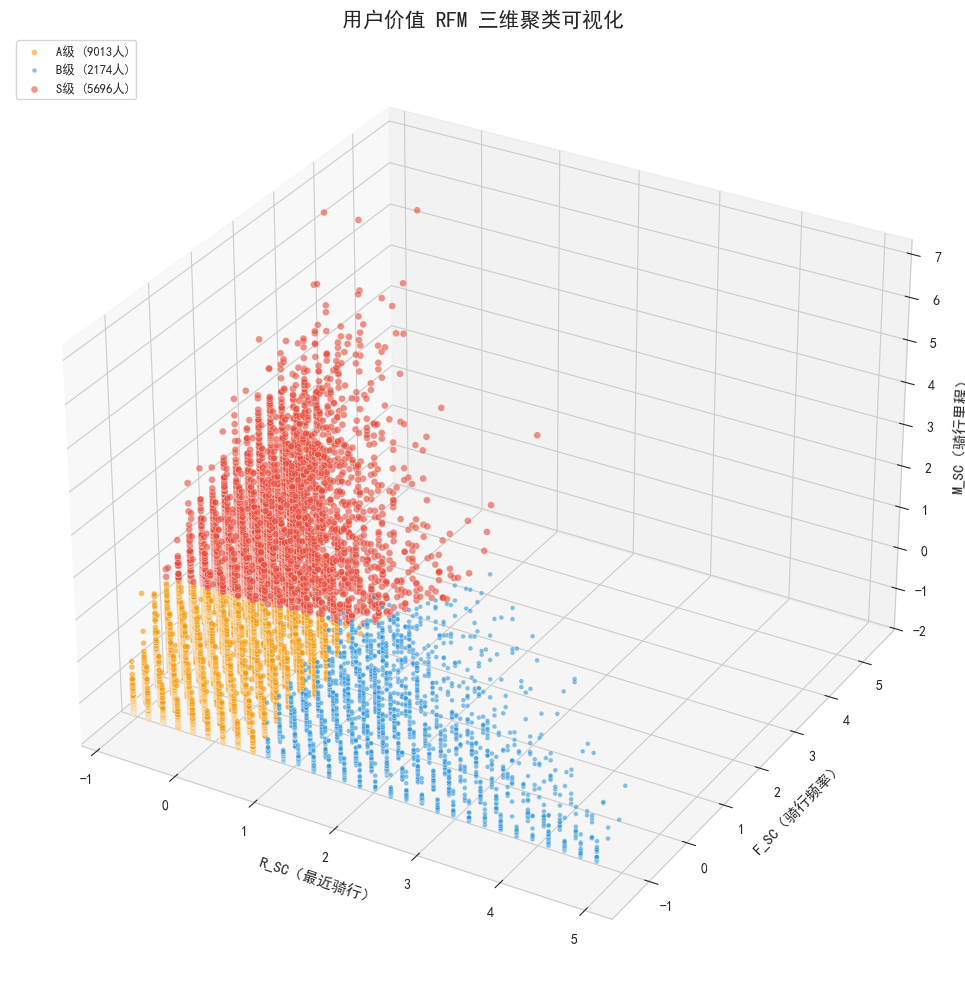

In [9]:
# ============================================================
# 图表：RFM 三维聚类可视化
# X=R_SC, Y=F_SC, Z=M_SC，按等级着色
# ============================================================
from mpl_toolkits.mplot3d import Axes3D

level_colors = {
    "S": "#E74C3C", "A": "#F39C12", "B": "#3498DB",
    "C": "#2ECC71", "D": "#95A5A6"
}
level_sizes = {"S": 25, "A": 18, "B": 12, "C": 8, "D": 5}

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

for level in sorted(rfm["level"].unique()):
    subset = rfm[rfm["level"] == level]
    ax.scatter(
        subset["R_SC"], subset["F_SC"], subset["M_SC"],
        c=level_colors.get(level, "gray"),
        label=f"{level}级 ({len(subset)}人)",
        s=level_sizes.get(level, 8),
        alpha=0.6,
        edgecolors="white",
        linewidth=0.3
    )

ax.set_xlabel("R_SC（最近骑行）", fontsize=11)
ax.set_ylabel("F_SC（骑行频率）", fontsize=11)
ax.set_zlabel("M_SC（骑行里程）", fontsize=11)
ax.set_title("用户价值 RFM 三维聚类可视化", fontsize=15, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


**R vs F 散点图**

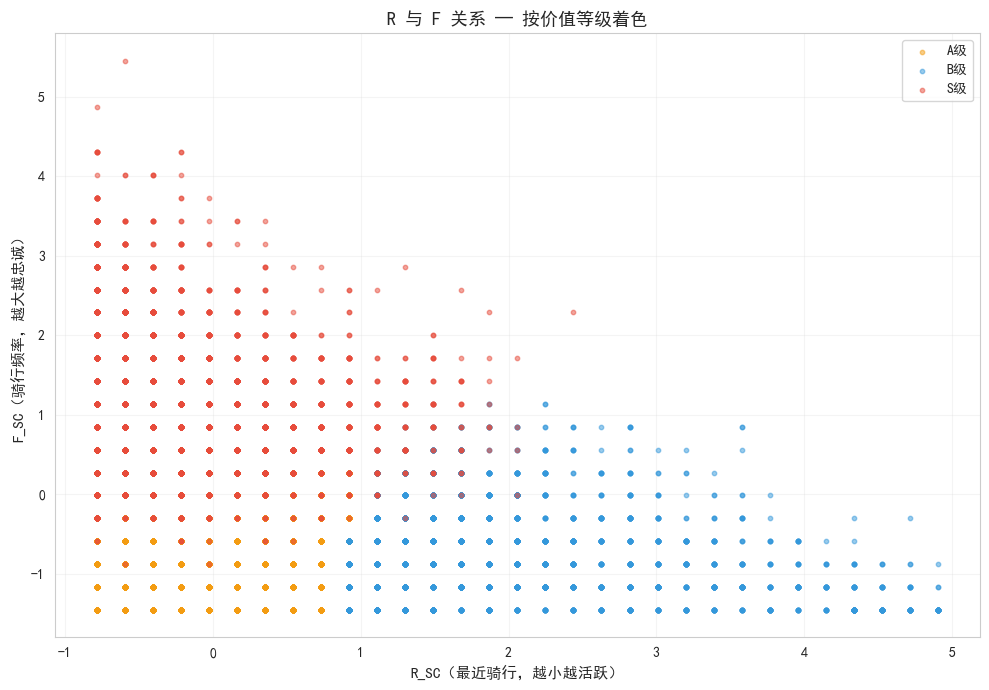

In [10]:
# ============================================================
# 图表：R_SC 与 F_SC 散点图（按等级着色）
# 左上角 = R小 + F大 = 高价值
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

for level in sorted(rfm["level"].unique()):
    subset = rfm[rfm["level"] == level]
    ax.scatter(
        subset["R_SC"], subset["F_SC"],
        c=level_colors.get(level, "gray"),
        label=f"{level}级",
        s=10, alpha=0.5
    )

ax.set_xlabel("R_SC（最近骑行，越小越活跃）", fontsize=11)
ax.set_ylabel("F_SC（骑行频率，越大越忠诚）", fontsize=11)
ax.set_title("R 与 F 关系 — 按价值等级着色", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


**F vs M 散点图**

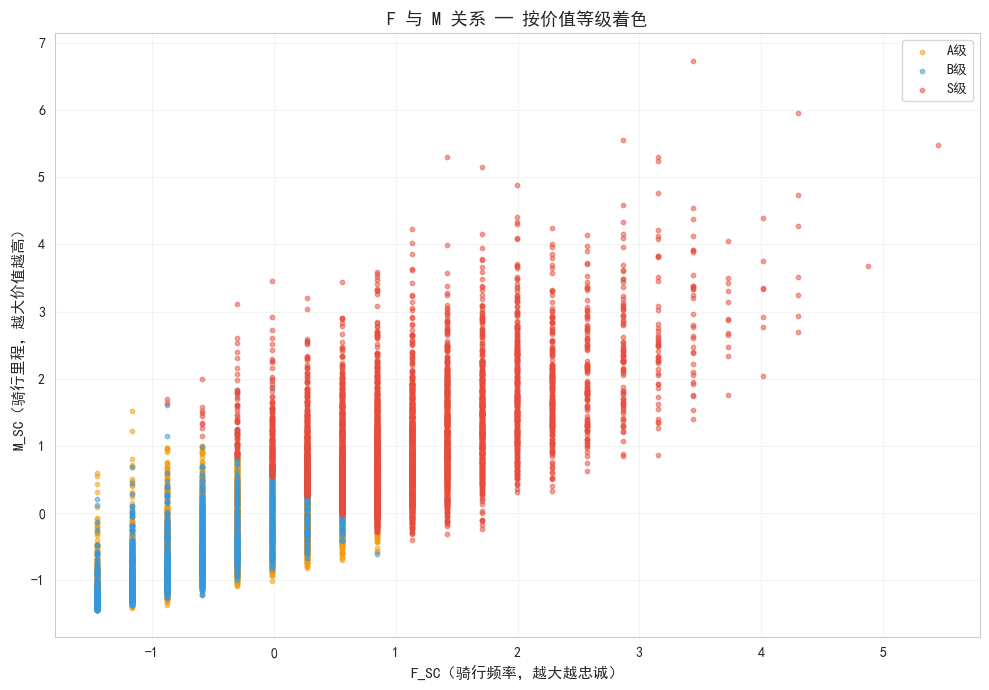

In [11]:
# ============================================================
# 图表：F_SC 与 M_SC 散点图（按等级着色）
# 右上角 = F大 + M大 = 高价值
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

for level in sorted(rfm["level"].unique()):
    subset = rfm[rfm["level"] == level]
    ax.scatter(
        subset["F_SC"], subset["M_SC"],
        c=level_colors.get(level, "gray"),
        label=f"{level}级",
        s=10, alpha=0.5
    )

ax.set_xlabel("F_SC（骑行频率，越大越忠诚）", fontsize=11)
ax.set_ylabel("M_SC（骑行里程，越大价值越高）", fontsize=11)
ax.set_title("F 与 M 关系 — 按价值等级着色", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


### C9 运营建议

**各等级汇总表**

In [12]:
# ============================================================
# 各等级 RFM 均值汇总表
# ============================================================
level_summary = rfm.groupby("level").agg(
    R_mean=("R", "mean"),
    F_mean=("F", "mean"),
    M_mean=("M", "mean"),
    用户数=("userid", "nunique")
).round(1)

level_summary["占比(%)"] = (
    level_summary["用户数"] / len(rfm) * 100
).round(1)

print("各等级 RFM 特征汇总：")
level_summary


各等级 RFM 特征汇总：


,R_mean,F_mean,M_mean,用户数,占比(%)
level,,,,,
A,2.70,4.30,6.00,9013,53.40
B,15.30,3.60,5.40,2174,12.90
S,2.20,9.80,16.40,5696,33.70


**差异化运营策略**

In [13]:
# ============================================================
# 差异化运营建议 — 按等级输出
# ============================================================
tips = {
    "S": {
        "特征": "最近使用 + 高频 + 长里程",
        "画像": "核心高价值用户，频次高、里程长、极度活跃",
        "策略": [
            "VIP 专属客服与优先服务通道",
            "月卡 / 季卡自动续费推荐",
            "新功能内测优先邀请",
            "骑行里程兑换积分奖励"
        ]
    },
    "A": {
        "特征": "较活跃 + 中高频 + 中高里程",
        "画像": "高潜力用户，有向 S 级升级空间",
        "策略": [
            "定向优惠券刺激更高频次",
            "邀请有礼、社交裂变拉新",
            "推送月度骑行报告",
            "月卡 vs 次卡成本对比引导升级"
        ]
    },
    "B": {
        "特征": "一般活跃 + 中等频次 + 中等里程",
        "画像": "普通用户，存在流失风险",
        "策略": [
            "天气晴好时 Push 唤醒",
            "节假日 / 周末限时优惠",
            "骑行挑战赛达标奖励",
            "通勤 / 休闲 / 健身场景推荐"
        ]
    },
    "C": {
        "特征": "较少使用 + 低频 + 低里程",
        "画像": "低活跃用户，可能已流失",
        "策略": [
            "大力度首单回归优惠券",
            "新功能 / 新路线体验邀请",
            "低门槛任务奖励（骑 1 次即奖）",
            "30 天未用自动发券预警"
        ]
    },
    "D": {
        "特征": "最久未骑 + 极低频 + 极低里程",
        "画像": "休眠 / 流失用户",
        "策略": [
            "强激励召回（免费骑 3 次）",
            "问卷调研流失原因",
            "品牌活动重新触达",
            "控制成本，设置召回 ROI 阈值"
        ]
    }
}

for lvl in ["S", "A", "B", "C", "D"][:best_k]:
    if lvl not in level_summary.index:
        continue
    t = tips[lvl]
    row = level_summary.loc[lvl]
    print()
    print("=" * 60)
    print(f"  [{lvl} 级] {t['特征']}")
    print("=" * 60)
    print(f"  用户数: {int(row['用户数'])} 人  ({row['占比(%)']}%)")
    print(f"  R: {row['R_mean']:.1f} 天  |  "
          f"F: {row['F_mean']:.1f} 次  |  "
          f"M: {row['M_mean']:.1f} km")
    print(f"  画像: {t['画像']}")
    print(f"  策略:")
    for i, s in enumerate(t["策略"], 1):
        print(f"    {i}. {s}")



  [S 级] 最近使用 + 高频 + 长里程
  用户数: 5696 人  (33.7%)
  R: 2.2 天  |  F: 9.8 次  |  M: 16.4 km
  画像: 核心高价值用户，频次高、里程长、极度活跃
  策略:
    1. VIP 专属客服与优先服务通道
    2. 月卡 / 季卡自动续费推荐
    3. 新功能内测优先邀请
    4. 骑行里程兑换积分奖励

  [A 级] 较活跃 + 中高频 + 中高里程
  用户数: 9013 人  (53.4%)
  R: 2.7 天  |  F: 4.3 次  |  M: 6.0 km
  画像: 高潜力用户，有向 S 级升级空间
  策略:
    1. 定向优惠券刺激更高频次
    2. 邀请有礼、社交裂变拉新
    3. 推送月度骑行报告
    4. 月卡 vs 次卡成本对比引导升级

  [B 级] 一般活跃 + 中等频次 + 中等里程
  用户数: 2174 人  (12.9%)
  R: 15.3 天  |  F: 3.6 次  |  M: 5.4 km
  画像: 普通用户，存在流失风险
  策略:
    1. 天气晴好时 Push 唤醒
    2. 节假日 / 周末限时优惠
    3. 骑行挑战赛达标奖励
    4. 通勤 / 休闲 / 健身场景推荐


### C10 保存结果

In [14]:
# ============================================================
# 保存分层结果到 CSV
# ============================================================
output_cols = ["userid", "R", "F", "M", "R_SC", "F_SC", "M_SC", "cluster", "level"]
rfm_output = rfm[output_cols].copy()

rfm_output.columns = [
    "userid",
    "recency(day)", "frequency(次)", "total_distance(km)",
    "R_SC", "F_SC", "M_SC",
    "cluster", "level"
]

output_path = "../data/共享单车_RFM分层.csv"
rfm_output.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"已保存: {output_path}")
print(f"维度:   {rfm_output.shape[0]} 行 x {rfm_output.shape[1]} 列")
print(f"用户:   {rfm_output['userid'].nunique()} 人")
print()
print("各等级分布：")
for lvl in ["S", "A", "B", "C", "D"][:best_k]:
    cnt = (rfm_output["level"] == lvl).sum()
    if cnt > 0:
        print(f"  {lvl} 级: {cnt} 人 ({cnt / len(rfm_output) * 100:.1f}%)")

print()
print("前 10 行预览：")
rfm_output.head(10)


已保存: ../data/共享单车_RFM分层.csv
维度:   16883 行 x 9 列
用户:   16883 人

各等级分布：
  S 级: 5696 人 (33.7%)
  A 级: 9013 人 (53.4%)
  B 级: 2174 人 (12.9%)

前 10 行预览：


,userid,recency(day),frequency(次),total_distance(km),R_SC,F_SC,M_SC,cluster,level
0,1,0,5,7.18,-0.79,-0.30,-0.35,2,A
1,3,3,8,8.49,-0.22,0.56,-0.15,2,A
2,6,0,2,2.58,-0.79,-1.17,-1.06,2,A
3,7,6,8,10.49,0.35,0.56,0.16,0,S
4,8,4,7,7.09,-0.03,0.27,-0.36,2,A
5,9,1,10,9.03,-0.60,1.14,-0.06,0,S
6,10,0,7,10.06,-0.79,0.27,0.10,2,A
7,11,0,6,6.08,-0.79,-0.02,-0.52,2,A
8,12,4,1,0.86,-0.03,-1.45,-1.33,2,A
9,13,15,4,5.30,2.06,-0.59,-0.64,1,B
